## Data loading

In [ ]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import ast
import pickle

In [41]:
# CONSTANTS AND PATHS
TRAIN_DIR = "data/BBDD"
TEST_DIR = "data/qsd1_w1"

In [42]:
def build_dataset(dataset_dir):
    """
    Build a dataset of images and their corresponding labels from a given directory.

    Parameters:
    dataset_dir (str): The path to the directory containing the dataset.

    Returns:
    pd.DataFrame: A DataFrame containing the image paths and their corresponding labels.
    """
    data = {}

    for file in os.listdir(dataset_dir):

        # Get filename without extension
        filename = os.path.splitext(file)[0]

        # Create entry if it doesn't already exist
        if filename not in data:
            data[filename] = {
                "image_path": None,
                "image": None,
                "artist": None,
                "artwork_name": None
            }

        # Load image
        if file.lower().endswith(".jpg"):
            image_path = os.path.join(dataset_dir, file)

            data[filename]["image_path"] = image_path
            data[filename]["image"] = cv2.imread(image_path)

        # Load label
        elif file.lower().endswith(".txt"):
            txt_path = os.path.join(dataset_dir, file)

            with open(txt_path, "r", encoding="utf-8") as f:
                content = f.read().strip()

            # Empty .txt file
            if not content:
                continue

            try:
                lines = list(ast.literal_eval(content))

                if len(lines) >= 2:
                    data[filename]["artist"] = lines[0]
                    data[filename]["artwork_name"] = lines[1]

            except (ValueError, SyntaxError):
                print(f"Warning: Could not parse label file: {txt_path}")

    # Convert dictionary to DataFrame
    df = pd.DataFrame.from_dict(data, orient="index")

    # Reset index
    df = df.reset_index(drop=True)

    return df

In [43]:
dataset = build_dataset(TRAIN_DIR)

In [44]:
dataset.head()

,image_path,image,artist,artwork_name
0,data/BBDD\bbdd_00000.jpg,"[[[87, 92, 95], [83, 88, 91], [82, 87, 90], [8...",Victor Perez-Porros,Des-li-zan-tes
1,data/BBDD\bbdd_00001.jpg,"[[[97, 121, 139], [97, 121, 139], [97, 121, 13...",Hugo Demarco,Reflecting Room
2,data/BBDD\bbdd_00002.jpg,"[[[126, 140, 159], [130, 144, 163], [124, 138,...",Unknown,Unknown
3,data/BBDD\bbdd_00003.jpg,"[[[29, 53, 65], [35, 61, 73], [32, 57, 73], [3...",Edvard Munch,Youth
4,data/BBDD\bbdd_00004.jpg,"[[[80, 96, 109], [69, 86, 99], [66, 86, 103], ...",Martin Carral,Ciclo espacial XXIV


## Basic histogram construction and plotting

In [45]:
BINS = 128

In [46]:
valid_images = dataset["image"].apply(
    lambda img: isinstance(img, np.ndarray)
    and img.ndim == 3
    and img.shape[2] == 3
)

dataset = dataset.loc[valid_images].reset_index(drop=True)

dataset["histogram"] = dataset["image"].apply(
    lambda img: np.concatenate([
        np.histogram(img[:, :, 0], bins=BINS, range=(0, 256))[0],
        np.histogram(img[:, :, 1], bins=BINS, range=(0, 256))[0],
        np.histogram(img[:, :, 2], bins=BINS, range=(0, 256))[0]
    ])
)

In [47]:
dataset.head()

,image_path,image,artist,artwork_name,histogram
0,data/BBDD\bbdd_00000.jpg,"[[[87, 92, 95], [83, 88, 91], [82, 87, 90], [8...",Victor Perez-Porros,Des-li-zan-tes,"[34057, 23515, 26700, 27401, 27084, 26981, 262..."
1,data/BBDD\bbdd_00001.jpg,"[[[97, 121, 139], [97, 121, 139], [97, 121, 13...",Hugo Demarco,Reflecting Room,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,data/BBDD\bbdd_00002.jpg,"[[[126, 140, 159], [130, 144, 163], [124, 138,...",Unknown,Unknown,"[2128, 4636, 7245, 6982, 5306, 2614, 952, 478,..."
3,data/BBDD\bbdd_00003.jpg,"[[[29, 53, 65], [35, 61, 73], [32, 57, 73], [3...",Edvard Munch,Youth,"[31312, 20805, 22947, 23140, 23088, 23038, 231..."
4,data/BBDD\bbdd_00004.jpg,"[[[80, 96, 109], [69, 86, 99], [66, 86, 103], ...",Martin Carral,Ciclo espacial XXIV,"[243, 121, 201, 230, 368, 680, 1767, 3751, 603..."


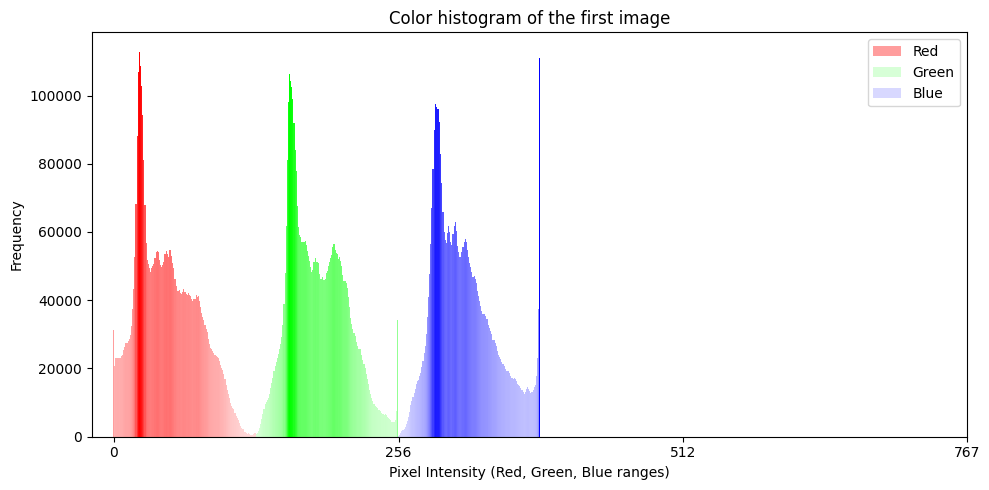

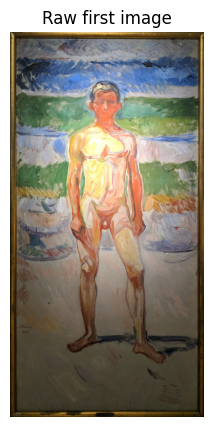

In [48]:
# Plot the histogram of the first image with one color per channel
histogram = np.asarray(dataset["histogram"].iloc[3])
channel_histograms = np.split(histogram, 3)
channel_colors = [(1, 0, 0), (0, 1, 0), (0, 0, 1)]
channel_names = ["Red", "Green", "Blue"]

plt.figure(figsize=(10, 5))
for channel_index, (channel_histogram, color, name) in enumerate(
    zip(channel_histograms, channel_colors, channel_names)
):
    x_values = np.arange(channel_index * BINS, (channel_index + 1) * BINS)
    maximum_frequency = channel_histogram.max()
    intensities = (
        channel_histogram / maximum_frequency
        if maximum_frequency > 0
        else np.zeros_like(channel_histogram, dtype=float)
    )
    bar_colors = [(*color, 0.15 + 0.85 * intensity) for intensity in intensities]
    plt.bar(x_values, channel_histogram, color=bar_colors, width=1.0, label=name)

plt.title("Color histogram of the first image")
plt.xlabel("Pixel Intensity (Red, Green, Blue ranges)")
plt.ylabel("Frequency")
plt.xticks([0, 256, 512, 767], ["0", "256", "512", "767"])
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.title("Raw first image")
plt.imshow(cv2.cvtColor(dataset["image"].iloc[3], cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

## Similarity measure function

In [49]:
def find_similar_images(target_image, dataset, top_n=5, method=cv2.HISTCMP_CORREL, plot=False, bins=256):
    """
    Find the most similar images in the dataset based on histogram comparison.

    Parameters:
    target_image (np.ndarray): The target image.
    dataset (pd.DataFrame): The dataset containing images and their histograms.
    top_n (int): The number of most similar images to return.

    Returns:
    pd.DataFrame: A DataFrame containing the top N most similar images and their similarity scores.
    """
    # Calculate similarity scores using correlation
    target_histogram = np.concatenate([
        np.histogram(target_image[:, :, 0], bins=bins, range=(0, 256))[0],
        np.histogram(target_image[:, :, 1], bins=bins, range=(0, 256))[0],
        np.histogram(target_image[:, :, 2], bins=bins, range=(0, 256))[0]
    ])
    
    dataset["similarity"] = dataset["histogram"].apply(
        lambda hist: cv2.compareHist(target_histogram.astype(np.float32), hist.astype(np.float32), cv2.HISTCMP_CORREL)
    )

    # Sort by similarity score in descending order
    similar_images = dataset.sort_values(by="similarity", ascending=False).head(top_n)
    
    if plot:
        plt.figure(figsize=(15, 5))
        plt.subplot(1, top_n + 1, 1)
        plt.imshow(cv2.cvtColor(target_image, cv2.COLOR_BGR2RGB))
        plt.title("Target Image")
        plt.axis("off")

        for i, (_, row) in enumerate(similar_images.iterrows(), start=2):
            plt.subplot(1, top_n + 1, i)
            plt.imshow(cv2.cvtColor(row["image"], cv2.COLOR_BGR2RGB))
            plt.title(f"Sim: {row['similarity']:.4f}")
            plt.axis("off")

        plt.tight_layout()
        plt.show()

    return similar_images[["image_path", "artist", "artwork_name", "similarity"]]

In [50]:
test_dataset = build_dataset(TEST_DIR)

In [51]:
test_dataset.head()

,image_path,image,artist,artwork_name
0,data/qsd1_w1\00000.jpg,"[[[177, 187, 187], [184, 194, 194], [190, 199,...",None,None
1,data/qsd1_w1\00001.jpg,"[[[179, 191, 191], [187, 199, 199], [192, 201,...",None,None
2,data/qsd1_w1\00002.jpg,"[[[151, 170, 178], [149, 168, 176], [143, 163,...",None,None
3,data/qsd1_w1\00003.jpg,"[[[182, 188, 187], [182, 188, 187], [183, 189,...",None,None
4,data/qsd1_w1\00004.jpg,"[[[7, 23, 40], [13, 29, 46], [10, 25, 44], [8,...",None,None


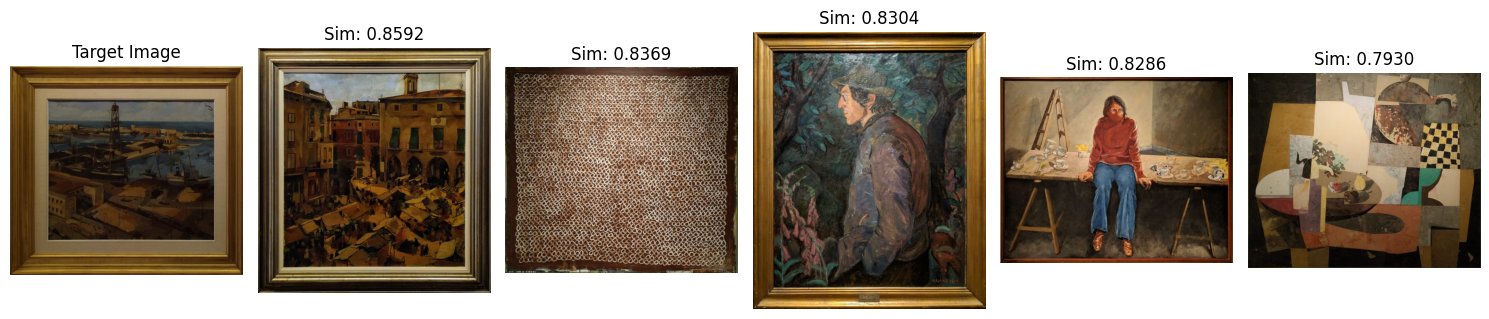

,image_path,artist,artwork_name,similarity
259,data/BBDD\bbdd_00259.jpg,Alfred Figueras,Mercat a la plaça de Manresa,0.859214
93,data/BBDD\bbdd_00093.jpg,Joan Hernandez Pijuan,Flors sobre terra torrada,0.836904
88,data/BBDD\bbdd_00088.jpg,Jan Moritz Kaland,Portrait of the painter Nikolai Astrup,0.830440
203,data/BBDD\bbdd_00203.jpg,Francesc Artigau,Retrat d'una noia,0.828638
86,data/BBDD\bbdd_00086.jpg,Miquel Rasero,S/t,0.792986


In [52]:
find_similar_images(test_dataset["image"].iloc[10], dataset, top_n=5, plot=True, bins=BINS)

## Evaluation of bin number and distance metric

In [55]:
import pickle

# Load the ground-truth correspondence for each test image.
correspondence_path = os.path.join(TEST_DIR, "gt_corresps.pkl")
with open(correspondence_path, "rb") as file:
    correspondences = pickle.load(file)

# Each entry contains the zero-based index of the matching training image.
correspondence_indices = [
    match[0] if match else None
    for match in correspondences
]

train_rows = dataset.reset_index(drop=True)
test_rows = test_dataset[test_dataset["image_path"].notna()].reset_index(drop=True)

correspondence_table = pd.DataFrame({
    "test_image": test_rows["image_path"],
    "train_index": correspondence_indices,
})
correspondence_table["train_image"] = correspondence_table["train_index"].apply(
    lambda index: train_rows.iloc[int(index)]["image_path"]
    if index is not None and 0 <= index < len(train_rows)
    else None
)
correspondence_table["artist"] = correspondence_table["train_index"].apply(
    lambda index: train_rows.iloc[int(index)]["artist"]
    if index is not None and 0 <= index < len(train_rows)
    else None
)
correspondence_table["artwork_name"] = correspondence_table["train_index"].apply(
    lambda index: train_rows.iloc[int(index)]["artwork_name"]
    if index is not None and 0 <= index < len(train_rows)
    else None
)

correspondence_table

,test_image,train_index,train_image,artist,artwork_name
0,data/qsd1_w1\00000.jpg,120,data/BBDD\bbdd_00120.jpg,Paul Klee,May come!
1,data/qsd1_w1\00001.jpg,170,data/BBDD\bbdd_00170.jpg,Alfred Figueras,Cap de Noia
2,data/qsd1_w1\00002.jpg,277,data/BBDD\bbdd_00277.jpg,Pere Santilari,Sifo groc
3,data/qsd1_w1\00003.jpg,227,data/BBDD\bbdd_00227.jpg,Perico Pastor,Mezzo
4,data/qsd1_w1\00004.jpg,251,data/BBDD\bbdd_00251.jpg,Francesc Artigau,Noia
5,data/qsd1_w1\00005.jpg,274,data/BBDD\bbdd_00274.jpg,Montserrat Clausells,Te de nit
6,data/qsd1_w1\00006.jpg,285,data/BBDD\bbdd_00285.jpg,Joan Hernandez Pijuan,Recordando una corrida
7,data/qsd1_w1\00007.jpg,258,data/BBDD\bbdd_00258.jpg,Sergi Barnils,"Mireu, tot ho faig nou"
8,data/qsd1_w1\00008.jpg,117,data/BBDD\bbdd_00117.jpg,Leticia Feduchi,Roba i cordill
9,data/qsd1_w1\00009.jpg,203,data/BBDD\bbdd_00203.jpg,Francesc Artigau,Retrat d'una noia


In [56]:
def create_bin_histograms(dataset, bins=BINS):
    """
    Create histograms for each image in the dataset.

    Parameters:
    dataset (pd.DataFrame): The dataset containing images.
    bins (int): The number of bins for the histogram.

    Returns:
    pd.DataFrame: The dataset with an additional column for histograms.
    """
    dataset["histogram"] = dataset["image"].apply(
        lambda img: np.concatenate([
            np.histogram(img[:, :, 0], bins=bins, range=(0, 256))[0],
            np.histogram(img[:, :, 1], bins=bins, range=(0, 256))[0],
            np.histogram(img[:, :, 2], bins=bins, range=(0, 256))[0]
        ])
    )
    return dataset

In [59]:
binlist = [32, 64, 128, 256]
distance_metrics = [cv2.HISTCMP_CORREL, cv2.HISTCMP_INTERSECT, cv2.HISTCMP_CHISQR, cv2.HISTCMP_BHATTACHARYYA]

# comparison using top 1 and top 5 accuracy with different histogram bin sizes
for bins in binlist:
    for distance_metric in distance_metrics:
        print(f"Evaluating with {bins} bins and distance metric {distance_metric}:")
        dataset_with_histograms = create_bin_histograms(dataset.copy(), bins=bins)
        
        top1_correct = 0
        top5_correct = 0
        total_images = len(test_rows)

        for idx, test_row in test_rows.iterrows():
            target_image = test_row["image"]
            similar_images = find_similar_images(target_image, dataset_with_histograms, top_n=5, plot=False, bins=bins, method=distance_metric)
            
            # Check if the correct match is in the top 1
            if similar_images.iloc[0]["image_path"] == correspondence_table.iloc[idx]["train_image"]:
                top1_correct += 1
            
            # Check if the correct match is in the top 5
            if correspondence_table.iloc[idx]["train_image"] in similar_images["image_path"].values:
                top5_correct += 1

        top1_accuracy = top1_correct / total_images
        top5_accuracy = top5_correct / total_images

        print(f"Top-1 Accuracy: {top1_accuracy:.4f}")
        print(f"Top-5 Accuracy: {top5_accuracy:.4f}\n")

Evaluating with 32 bins and distance metric 0:
Top-1 Accuracy: 0.3000
Top-5 Accuracy: 0.4000

Evaluating with 32 bins and distance metric 2:
Top-1 Accuracy: 0.3000
Top-5 Accuracy: 0.4000

Evaluating with 32 bins and distance metric 1:
Top-1 Accuracy: 0.3000
Top-5 Accuracy: 0.4000

Evaluating with 32 bins and distance metric 3:
Top-1 Accuracy: 0.3000
Top-5 Accuracy: 0.4000

Evaluating with 64 bins and distance metric 0:
Top-1 Accuracy: 0.3000
Top-5 Accuracy: 0.4000

Evaluating with 64 bins and distance metric 2:
Top-1 Accuracy: 0.3000
Top-5 Accuracy: 0.4000

Evaluating with 64 bins and distance metric 1:
Top-1 Accuracy: 0.3000
Top-5 Accuracy: 0.4000

Evaluating with 64 bins and distance metric 3:
Top-1 Accuracy: 0.3000
Top-5 Accuracy: 0.4000

Evaluating with 128 bins and distance metric 0:
Top-1 Accuracy: 0.2667
Top-5 Accuracy: 0.3667

Evaluating with 128 bins and distance metric 2:
Top-1 Accuracy: 0.2667
Top-5 Accuracy: 0.3667

Evaluating with 128 bins and distance metric 1:
Top-1 Accu